# Архитектура: глубина vs ширина

> Сорочан Дмитрий, [@legenda0008](https://t.me/legenda0008)

**Тема 24:** исследовать влияние числа слоев и нейронов на аппроксимацию, сравнить shallow и deep сети при одинаковом числе параметров и построить heatmap `ширина × глубина → качество`.

Основные датасеты -- **MNIST** и **Fashion-MNIST**. Архитектуру дополнительно никак не усложняю, только: `Linear + ReLU`, без BatchNorm, residual connections и scheduler'ов, чтобы не смешивать эффект depth/width с другими приемами _(можно отдельный ресерч на эту тему следать)_.


## Теоретическая справка

### Глубина и ширина

Пусть сеть имеет `d` скрытых слоев одинаковой ширины `w`. Для входа из 784 пикселей и 10 классов:

$$
    P(d, w)
    = (784 + 1) \cdot w + (d - 1) \cdot (w + 1) \cdot w + (w + 1) \cdot 10.
$$

Поэтому сравнение при одинаковой ширине -- не то же самое, что сравнению при одинаковой сложности: при росте глубины число параметров быстро растет из-за матриц `w × w`. **Буду сравнивать и то, и то.**

### Теорема об универсальной аппроксимации

Классическая теорема об универсальной аппроксимации говорит, что feed-forward сеть с одним скрытым слоем и достаточно большим числом нейронов при подходящей нелинейной активации способна сколь угодно точно приблизить непрерывную функцию на компактном множестве.

**Почему это -- не панацея:**

- теорема утверждает существование весов, но не говорит, как их найти;
- она не ограничивает требуемую ширину -- shallow-сеть может потребовать очень много нейронов;
- она не гарантирует хорошее обобщение;
- композиционные функции часто представляются глубокими сетями параметрически эффективнее;
- очень глубокая обычная MLP без residual connections, наоборот, может хуже оптимизироваться.


In [1]:
import gc
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import FashionMNIST, MNIST


SEED = 143
CACHE_DIR = Path.home() / ".cache" / "mlstart_hw03"
REPORT_DIR = Path("report")
FIGURES_DIR = REPORT_DIR / "figures"
REPORT_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

VAL_SIZE = 10_000
GRID_TRAIN_SIZE = 20_000
BATCH_SIZE = 256
GRID_EPOCHS = 3
CURVE_EPOCHS = 10
MATCHED_EPOCHS = 3
FINAL_EPOCHS = 8
LR = 1e-3

DEPTHS = [1, 2, 3, 5, 10, 20, 50, 100]
WIDTHS = [8, 16, 32, 64, 128, 256]
PARAMETER_BUDGETS = [50_000, 150_000, 500_000]
MATCHED_DEPTHS = [1, 2, 5, 10, 20, 50, 100]
CURVE_CONFIGS = [(1, 256), (5, 128), (20, 64), (100, 32)]

sns.set_theme(style="whitegrid")
print("device:", DEVICE)


device: mps


Достаточно широкая выборка параметров глубины и ширины.

После выбора архитектуры лучшая MLP переобучается на всей официальной train-части и только затем один раз оценивается на official test.


In [2]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_dataset(dataset_class):
    train_raw = dataset_class(CACHE_DIR, train=True, download=True)
    test_raw = dataset_class(CACHE_DIR, train=False, download=True)

    X = train_raw.data.numpy().astype(np.float32) / 255.0
    y = train_raw.targets.numpy()
    X_test = test_raw.data.numpy().astype(np.float32) / 255.0
    y_test = test_raw.targets.numpy()

    train_index, val_index = train_test_split(
        np.arange(len(y)),
        test_size=VAL_SIZE,
        stratify=y,
        random_state=SEED,
    )

    mean = X[train_index].mean()
    std = X[train_index].std()

    X_train = (X[train_index] - mean) / std
    X_val = (X[val_index] - mean) / std
    X_test = (X_test - mean) / std

    y_train = y[train_index]
    y_val = y[val_index]

    grid_index, _ = train_test_split(
        np.arange(len(y_train)),
        train_size=GRID_TRAIN_SIZE,
        stratify=y_train,
        random_state=SEED,
    )

    train_dataset = TensorDataset(
        torch.from_numpy(X_train[:, None]),
        torch.from_numpy(y_train).long(),
    )
    grid_dataset = TensorDataset(
        torch.from_numpy(X_train[grid_index, None]),
        torch.from_numpy(y_train[grid_index]).long(),
    )
    val_dataset = TensorDataset(
        torch.from_numpy(X_val[:, None]),
        torch.from_numpy(y_val).long(),
    )
    test_dataset = TensorDataset(
        torch.from_numpy(X_test[:, None]),
        torch.from_numpy(y_test).long(),
    )

    return {
        "train": train_dataset,
        "grid": grid_dataset,
        "val": val_dataset,
        "test": test_dataset,
        "mean": mean,
        "std": std,
        "train_index": train_index,
        "val_index": val_index,
    }


def make_loader(dataset, shuffle=False):
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator if shuffle else None,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


In [3]:
class MLP(nn.Module):
    def __init__(self, depth, width, n_classes=10):
        super().__init__()

        layers = [nn.Flatten()]
        in_features = 28 * 28

        for _ in range(depth):
            layers.append(nn.Linear(in_features, width))
            layers.append(nn.ReLU())
            in_features = width

        layers.append(nn.Linear(in_features, n_classes))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def parameter_count(depth, width):
    return (784 + 1) * width + (depth - 1) * (width + 1) * width + (width + 1) * 10


def width_for_budget(depth, budget):
    widths = np.arange(4, 2049)
    counts = np.array([parameter_count(depth, width) for width in widths])
    return int(widths[np.abs(counts - budget).argmin()])


## Train loop

Optimizer, learning rate, loss и число эпох фиксированы внутри каждого типа сравнения. 

Early stopping в sweep не использую: иначе разные архитектуры фактически получили бы разный training budget.


In [4]:
def evaluate(model, loader, loss_fn):
    model.eval()
    losses = []
    y_true = []
    y_pred = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            losses.append(loss.item() * len(y_batch))
            y_true.append(y_batch.cpu().numpy())
            y_pred.append(logits.argmax(dim=1).cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    return {
        "loss": sum(losses) / len(loader.dataset),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true,
        "y_pred": y_pred,
    }


def fit_model(depth, width, train_dataset, val_dataset, epochs):
    set_seed()

    model = MLP(depth, width).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.CrossEntropyLoss()

    train_loader = make_loader(train_dataset, shuffle=True)
    val_loader = make_loader(val_dataset)

    history = []
    started = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        train_true = []
        train_pred = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(y_batch)
            train_true.append(y_batch.cpu().numpy())
            train_pred.append(logits.argmax(dim=1).detach().cpu().numpy())

        train_true = np.concatenate(train_true)
        train_pred = np.concatenate(train_pred)
        val_metrics = evaluate(model, val_loader, loss_fn)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss / len(train_dataset),
            "train_accuracy": accuracy_score(train_true, train_pred),
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
        })

    elapsed = time.perf_counter() - started
    return model, pd.DataFrame(history), elapsed


## Ширина × глубина -- MNIST


In [5]:
mnist_data = load_dataset(MNIST)

mnist_grid_results = []

for depth in DEPTHS:
    for width in WIDTHS:
        print(f"MNIST: depth={depth}, width={width}")
        model, history, elapsed = fit_model(
            depth,
            width,
            mnist_data["grid"],
            mnist_data["val"],
            GRID_EPOCHS,
        )

        last = history.iloc[-1]
        mnist_grid_results.append({
            "dataset": "MNIST",
            "depth": depth,
            "width": width,
            "parameters": count_parameters(model),
            "val_accuracy": last["val_accuracy"],
            "val_macro_f1": last["val_macro_f1"],
            "val_loss": last["val_loss"],
            "train_time_sec": elapsed,
        })

        pd.DataFrame(mnist_grid_results).to_csv(
            REPORT_DIR / "mnist_architecture_results.csv",
            index=False,
        )

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

mnist_grid_results = pd.DataFrame(mnist_grid_results)
mnist_grid_results.sort_values("val_accuracy", ascending=False).head(10)


MNIST: depth=1, width=8
MNIST: depth=1, width=16
MNIST: depth=1, width=32
MNIST: depth=1, width=64
MNIST: depth=1, width=128
MNIST: depth=1, width=256
MNIST: depth=2, width=8
MNIST: depth=2, width=16
MNIST: depth=2, width=32
MNIST: depth=2, width=64
MNIST: depth=2, width=128
MNIST: depth=2, width=256
MNIST: depth=3, width=8
MNIST: depth=3, width=16
MNIST: depth=3, width=32
MNIST: depth=3, width=64
MNIST: depth=3, width=128
MNIST: depth=3, width=256
MNIST: depth=5, width=8
MNIST: depth=5, width=16
MNIST: depth=5, width=32
MNIST: depth=5, width=64
MNIST: depth=5, width=128
MNIST: depth=5, width=256
MNIST: depth=10, width=8
MNIST: depth=10, width=16
MNIST: depth=10, width=32
MNIST: depth=10, width=64
MNIST: depth=10, width=128
MNIST: depth=10, width=256
MNIST: depth=20, width=8
MNIST: depth=20, width=16
MNIST: depth=20, width=32
MNIST: depth=20, width=64
MNIST: depth=20, width=128
MNIST: depth=20, width=256
MNIST: depth=50, width=8
MNIST: depth=50, width=16
MNIST: depth=50, width=32
MNIST

,dataset,depth,width,parameters,val_accuracy,val_macro_f1,val_loss,train_time_sec
17,MNIST,3,256,335114,0.9522,0.951911,0.153595,0.897586
11,MNIST,2,256,269322,0.9511,0.950794,0.161234,0.889576
5,MNIST,1,256,203530,0.9488,0.948465,0.181949,0.810199
23,MNIST,5,256,466698,0.9449,0.944471,0.176117,1.087235
16,MNIST,3,128,134794,0.9418,0.941202,0.195535,0.845954
10,MNIST,2,128,118282,0.9365,0.935926,0.211415,0.798291
4,MNIST,1,128,101770,0.9355,0.934909,0.224295,0.755735
22,MNIST,5,128,167818,0.9302,0.929649,0.222335,1.016560
9,MNIST,2,64,55050,0.9267,0.925842,0.249954,0.773613
15,MNIST,3,64,59210,0.9240,0.923115,0.256914,0.823808


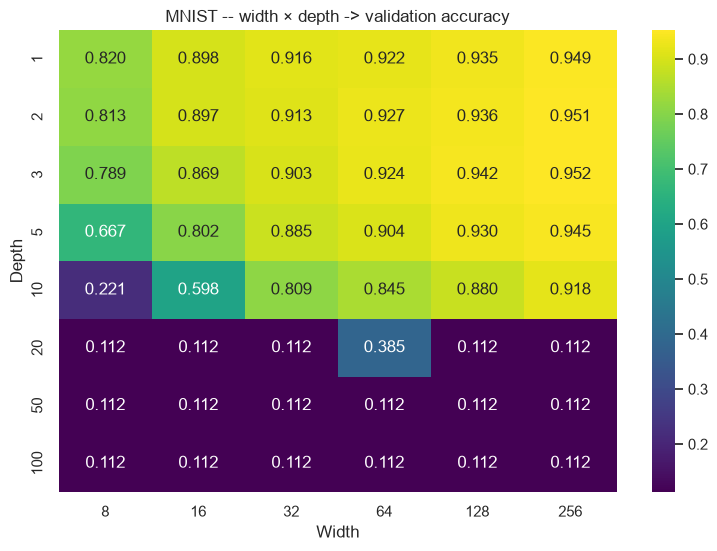

In [6]:
mnist_accuracy_heatmap = mnist_grid_results.pivot(index="depth", columns="width", values="val_accuracy")

plt.figure(figsize=(9, 6))
sns.heatmap(mnist_accuracy_heatmap, annot=True, fmt=".3f", cmap="viridis")
plt.title("MNIST -- width × depth -> validation accuracy")
plt.xlabel("Width")
plt.ylabel("Depth")
plt.savefig(FIGURES_DIR / "mnist_accuracy_heatmap.png", bbox_inches="tight")
plt.show()


Лучше всего себя показали широкие неглубокие сети.

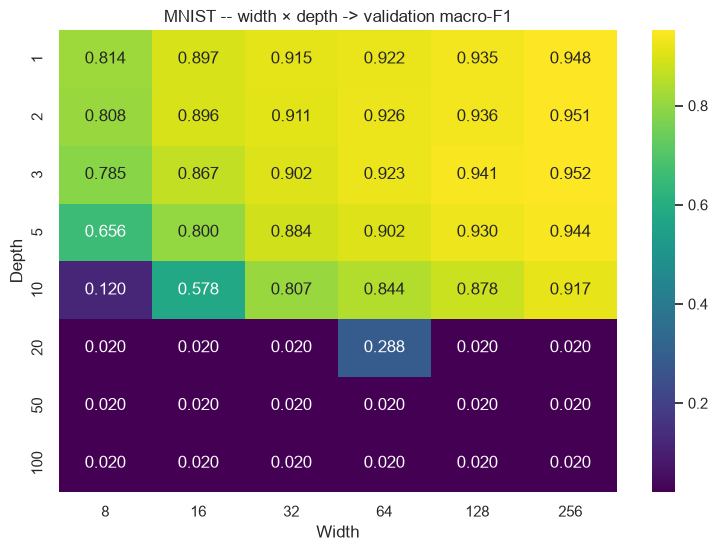

In [7]:
mnist_f1_heatmap = mnist_grid_results.pivot(index="depth", columns="width", values="val_macro_f1")

plt.figure(figsize=(9, 6))
sns.heatmap(mnist_f1_heatmap, annot=True, fmt=".3f", cmap="viridis")
plt.title("MNIST -- width × depth -> validation macro-F1")
plt.xlabel("Width")
plt.ylabel("Depth")
plt.savefig(FIGURES_DIR / "mnist_f1_heatmap.png", bbox_inches="tight")
plt.show()


Аналогично.

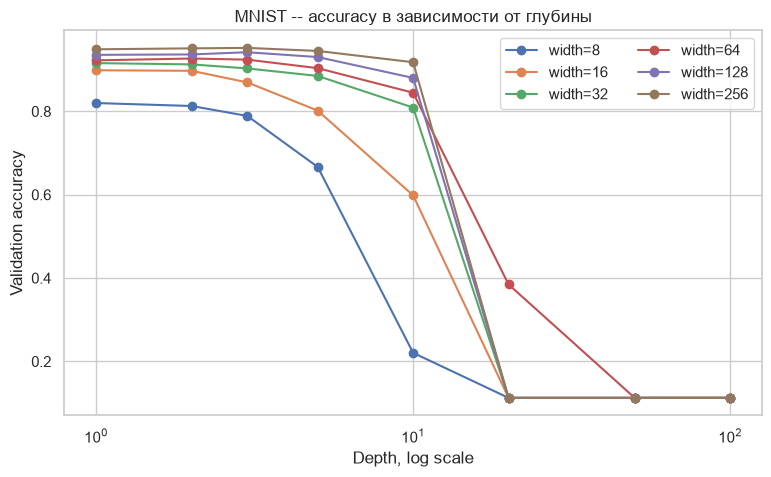

In [8]:
plt.figure(figsize=(9, 5))
for width in WIDTHS:
    part = mnist_grid_results[mnist_grid_results["width"] == width]
    plt.plot(part["depth"], part["val_accuracy"], marker="o", label=f"width={width}")

plt.xscale("log")
plt.title("MNIST -- accuracy в зависимости от глубины")
plt.xlabel("Depth, log scale")
plt.ylabel("Validation accuracy")
plt.legend(ncol=2)
plt.savefig(FIGURES_DIR / "mnist_accuracy_vs_depth.png", bbox_inches="tight")
plt.show()


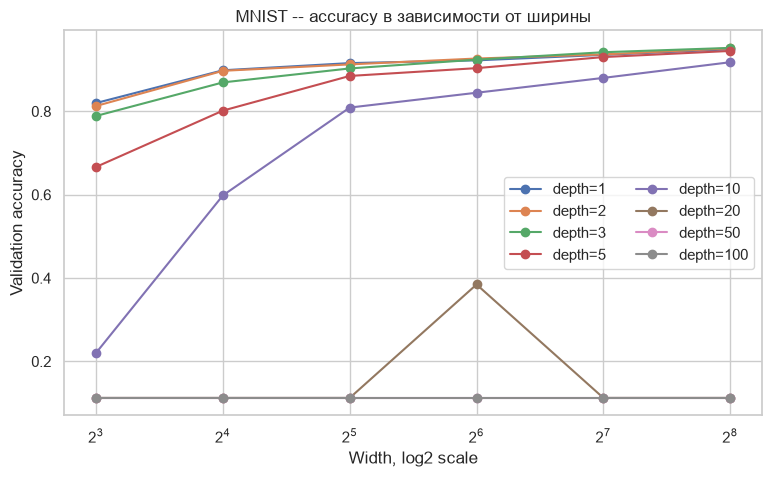

In [9]:
plt.figure(figsize=(9, 5))
for depth in DEPTHS:
    part = mnist_grid_results[mnist_grid_results["depth"] == depth]
    plt.plot(part["width"], part["val_accuracy"], marker="o", label=f"depth={depth}")

plt.xscale("log", base=2)
plt.title("MNIST -- accuracy в зависимости от ширины")
plt.xlabel("Width, log2 scale")
plt.ylabel("Validation accuracy")
plt.legend(ncol=2)
plt.savefig(FIGURES_DIR / "mnist_accuracy_vs_width.png", bbox_inches="tight")
plt.show()


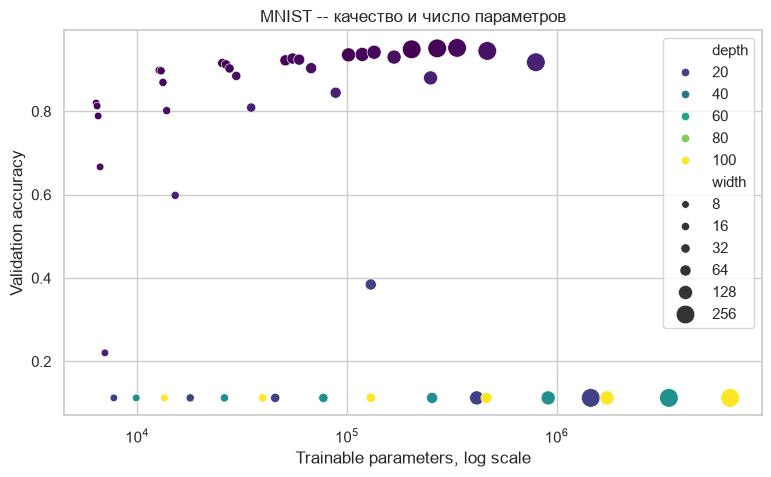

In [10]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=mnist_grid_results,
    x="parameters",
    y="val_accuracy",
    hue="depth",
    size="width",
    palette="viridis",
    sizes=(30, 180),
)
plt.xscale("log")
plt.title("MNIST -- качество и число параметров")
plt.xlabel("Trainable parameters, log scale")
plt.ylabel("Validation accuracy")
plt.savefig(FIGURES_DIR / "mnist_accuracy_vs_parameters.png", bbox_inches="tight")
plt.show()


## Ширина × глубина -- Fashion-MNIST


In [11]:
fashion_data = load_dataset(FashionMNIST)

fashion_grid_results = []

for depth in DEPTHS:
    for width in WIDTHS:
        print(f"Fashion-MNIST: depth={depth}, width={width}")
        model, history, elapsed = fit_model(
            depth,
            width,
            fashion_data["grid"],
            fashion_data["val"],
            GRID_EPOCHS,
        )

        last = history.iloc[-1]
        fashion_grid_results.append({
            "dataset": "Fashion-MNIST",
            "depth": depth,
            "width": width,
            "parameters": count_parameters(model),
            "val_accuracy": last["val_accuracy"],
            "val_macro_f1": last["val_macro_f1"],
            "val_loss": last["val_loss"],
            "train_time_sec": elapsed,
        })

        pd.DataFrame(fashion_grid_results).to_csv(
            REPORT_DIR / "fashion_architecture_results.csv",
            index=False,
        )

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

fashion_grid_results = pd.DataFrame(fashion_grid_results)
fashion_grid_results.sort_values("val_accuracy", ascending=False).head(10)


Fashion-MNIST: depth=1, width=8
Fashion-MNIST: depth=1, width=16
Fashion-MNIST: depth=1, width=32
Fashion-MNIST: depth=1, width=64
Fashion-MNIST: depth=1, width=128
Fashion-MNIST: depth=1, width=256
Fashion-MNIST: depth=2, width=8
Fashion-MNIST: depth=2, width=16
Fashion-MNIST: depth=2, width=32
Fashion-MNIST: depth=2, width=64
Fashion-MNIST: depth=2, width=128
Fashion-MNIST: depth=2, width=256
Fashion-MNIST: depth=3, width=8
Fashion-MNIST: depth=3, width=16
Fashion-MNIST: depth=3, width=32
Fashion-MNIST: depth=3, width=64
Fashion-MNIST: depth=3, width=128
Fashion-MNIST: depth=3, width=256
Fashion-MNIST: depth=5, width=8
Fashion-MNIST: depth=5, width=16
Fashion-MNIST: depth=5, width=32
Fashion-MNIST: depth=5, width=64
Fashion-MNIST: depth=5, width=128
Fashion-MNIST: depth=5, width=256
Fashion-MNIST: depth=10, width=8
Fashion-MNIST: depth=10, width=16
Fashion-MNIST: depth=10, width=32
Fashion-MNIST: depth=10, width=64
Fashion-MNIST: depth=10, width=128
Fashion-MNIST: depth=10, width=256

,dataset,depth,width,parameters,val_accuracy,val_macro_f1,val_loss,train_time_sec
23,Fashion-MNIST,5,256,466698,0.8570,0.857623,0.397579,1.079597
11,Fashion-MNIST,2,256,269322,0.8569,0.857981,0.391507,0.745265
5,Fashion-MNIST,1,256,203530,0.8549,0.856071,0.406327,0.682745
17,Fashion-MNIST,3,256,335114,0.8530,0.853318,0.403731,0.905018
4,Fashion-MNIST,1,128,101770,0.8527,0.853754,0.409986,0.664467
16,Fashion-MNIST,3,128,134794,0.8523,0.852507,0.411046,0.847882
10,Fashion-MNIST,2,128,118282,0.8511,0.852554,0.409583,0.736328
3,Fashion-MNIST,1,64,50890,0.8510,0.851155,0.418248,0.665703
8,Fashion-MNIST,2,32,26506,0.8462,0.846432,0.438273,0.729353
9,Fashion-MNIST,2,64,55050,0.8448,0.845572,0.427346,0.717549


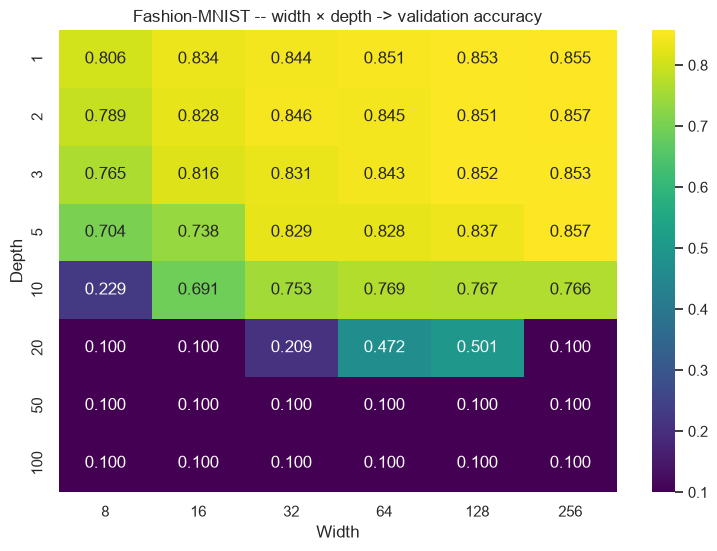

In [12]:
fashion_accuracy_heatmap = fashion_grid_results.pivot(index="depth", columns="width", values="val_accuracy")

plt.figure(figsize=(9, 6))
sns.heatmap(fashion_accuracy_heatmap, annot=True, fmt=".3f", cmap="viridis")
plt.title("Fashion-MNIST -- width × depth -> validation accuracy")
plt.xlabel("Width")
plt.ylabel("Depth")
plt.savefig(FIGURES_DIR / "fashion_accuracy_heatmap.png", bbox_inches="tight")
plt.show()


Тут тоже огромная глубина пошла в минус (вероятно, из-за затухания градиентов), при этом дальнейшее увеличение ширины после $\sim 32$ особого прироста не дало.

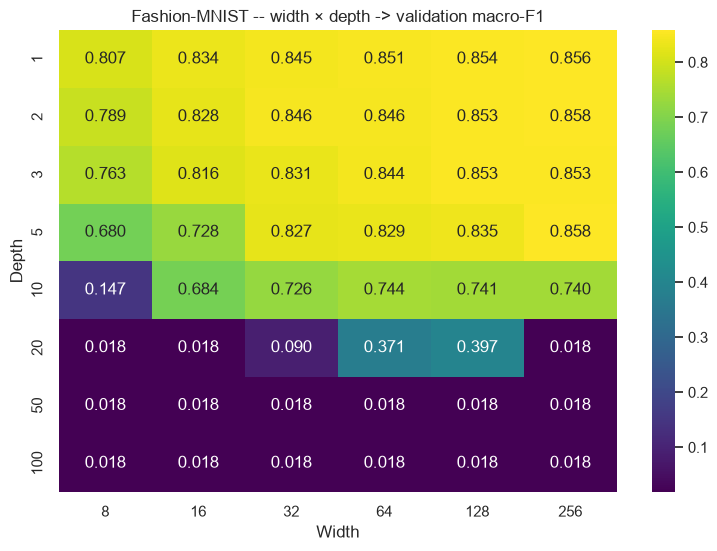

In [13]:
fashion_f1_heatmap = fashion_grid_results.pivot(index="depth", columns="width", values="val_macro_f1")

plt.figure(figsize=(9, 6))
sns.heatmap(fashion_f1_heatmap, annot=True, fmt=".3f", cmap="viridis")
plt.title("Fashion-MNIST -- width × depth -> validation macro-F1")
plt.xlabel("Width")
plt.ylabel("Depth")
plt.savefig(FIGURES_DIR / "fashion_f1_heatmap.png", bbox_inches="tight")
plt.show()


Same.

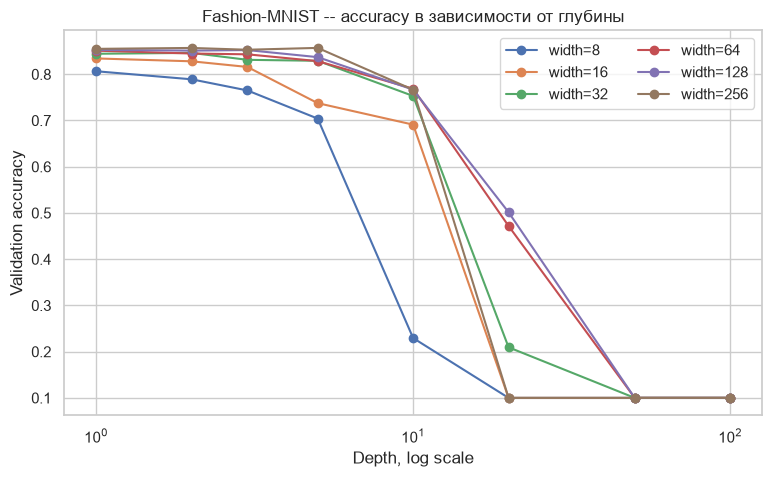

In [14]:
plt.figure(figsize=(9, 5))
for width in WIDTHS:
    part = fashion_grid_results[fashion_grid_results["width"] == width]
    plt.plot(part["depth"], part["val_accuracy"], marker="o", label=f"width={width}")

plt.xscale("log")
plt.title("Fashion-MNIST -- accuracy в зависимости от глубины")
plt.xlabel("Depth, log scale")
plt.ylabel("Validation accuracy")
plt.legend(ncol=2)
plt.savefig(FIGURES_DIR / "fashion_accuracy_vs_depth.png", bbox_inches="tight")
plt.show()


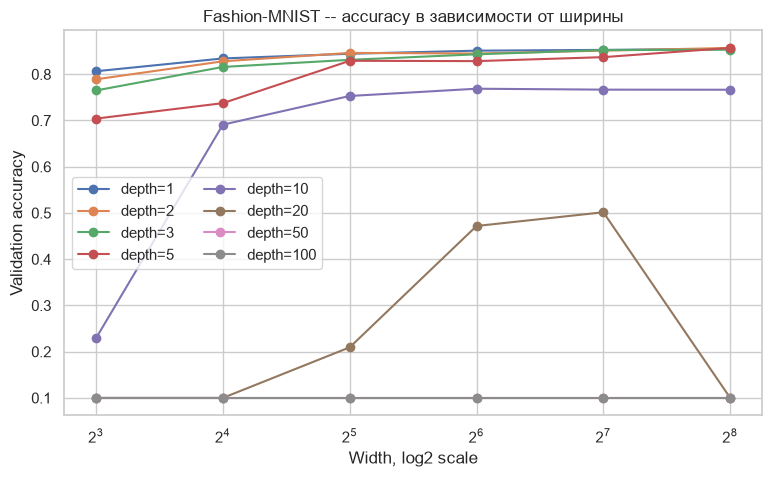

In [15]:
plt.figure(figsize=(9, 5))
for depth in DEPTHS:
    part = fashion_grid_results[fashion_grid_results["depth"] == depth]
    plt.plot(part["width"], part["val_accuracy"], marker="o", label=f"depth={depth}")

plt.xscale("log", base=2)
plt.title("Fashion-MNIST -- accuracy в зависимости от ширины")
plt.xlabel("Width, log2 scale")
plt.ylabel("Validation accuracy")
plt.legend(ncol=2)
plt.savefig(FIGURES_DIR / "fashion_accuracy_vs_width.png", bbox_inches="tight")
plt.show()


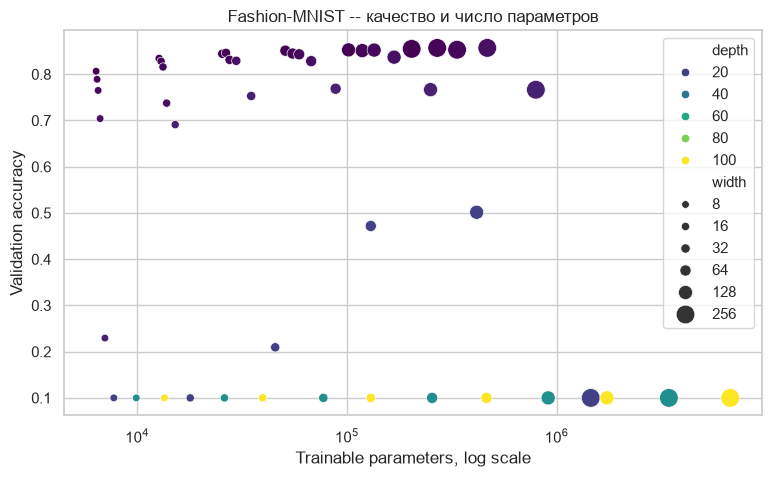

In [16]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=fashion_grid_results,
    x="parameters",
    y="val_accuracy",
    hue="depth",
    size="width",
    palette="viridis",
    sizes=(30, 180),
)
plt.xscale("log")
plt.title("Fashion-MNIST -- качество и число параметров")
plt.xlabel("Trainable parameters, log scale")
plt.ylabel("Validation accuracy")
plt.savefig(FIGURES_DIR / "fashion_accuracy_vs_parameters.png", bbox_inches="tight")
plt.show()


## Learning curves

Heatmap показывает финальную точку после фиксированного числа эпох, но не показывает динамику оптимизации. 

Для нескольких характерных архитектур отдельно строю learning curves на более длинном обучении _(для всех строить больно)_.


In [17]:
def run_learning_curves(dataset_name, data):
    histories = {}

    for depth, width in CURVE_CONFIGS:
        print(f"{dataset_name}: depth={depth}, width={width}")
        model, history, elapsed = fit_model(
            depth,
            width,
            data["grid"],
            data["val"],
            CURVE_EPOCHS,
        )
        history["depth"] = depth
        history["width"] = width
        history["train_time_sec"] = elapsed
        histories[(depth, width)] = history
        del model

    return histories


mnist_histories = run_learning_curves("MNIST", mnist_data)


MNIST: depth=1, width=256
MNIST: depth=5, width=128
MNIST: depth=20, width=64
MNIST: depth=100, width=32


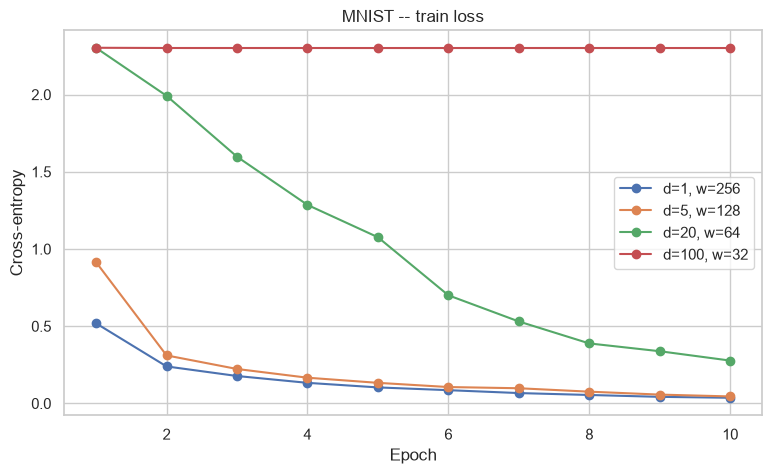

In [18]:
plt.figure(figsize=(9, 5))
for (depth, width), history in mnist_histories.items():
    plt.plot(history["epoch"], history["train_loss"], marker="o", label=f"d={depth}, w={width}")

plt.title("MNIST -- train loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy")
plt.legend()
plt.savefig(FIGURES_DIR / "mnist_learning_curve_train_loss.png", bbox_inches="tight")
plt.show()


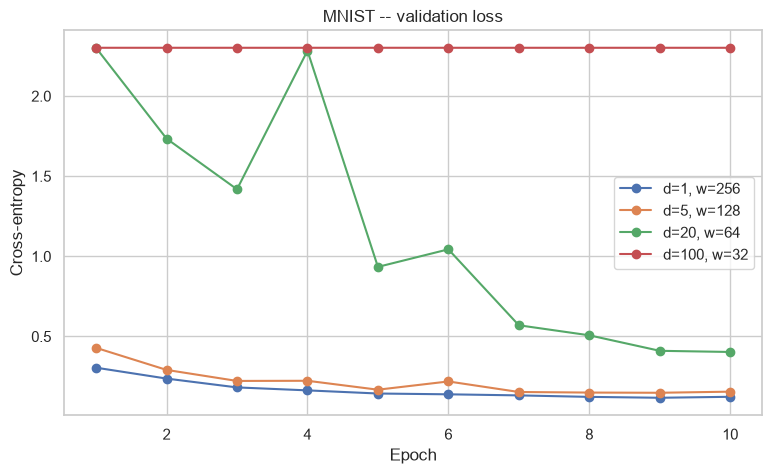

In [19]:
plt.figure(figsize=(9, 5))
for (depth, width), history in mnist_histories.items():
    plt.plot(history["epoch"], history["val_loss"], marker="o", label=f"d={depth}, w={width}")

plt.title("MNIST -- validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy")
plt.legend()
plt.savefig(FIGURES_DIR / "mnist_learning_curve_val_loss.png", bbox_inches="tight")
plt.show()


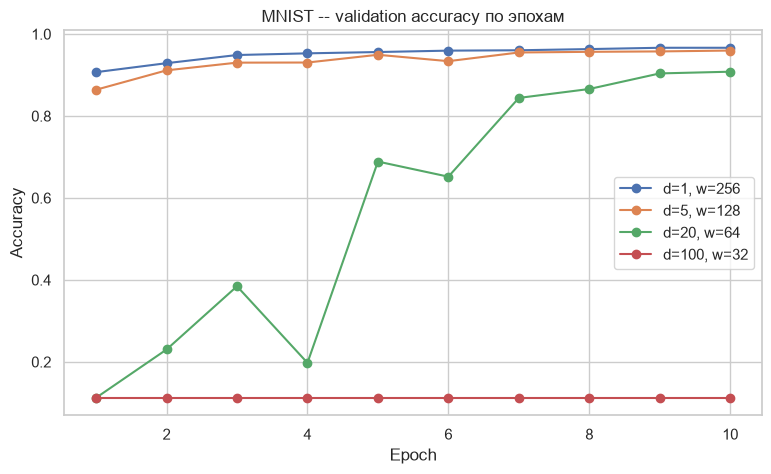

In [20]:
plt.figure(figsize=(9, 5))
for (depth, width), history in mnist_histories.items():
    plt.plot(history["epoch"], history["val_accuracy"], marker="o", label=f"d={depth}, w={width}")

plt.title("MNIST -- validation accuracy по эпохам")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig(FIGURES_DIR / "mnist_learning_curve_accuracy.png", bbox_inches="tight")
plt.show()


In [21]:
fashion_histories = run_learning_curves("Fashion-MNIST", fashion_data)


Fashion-MNIST: depth=1, width=256
Fashion-MNIST: depth=5, width=128
Fashion-MNIST: depth=20, width=64
Fashion-MNIST: depth=100, width=32


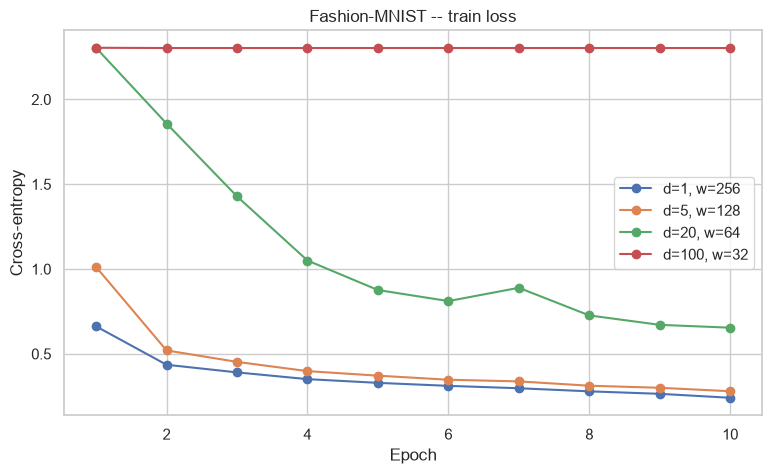

In [22]:
plt.figure(figsize=(9, 5))
for (depth, width), history in fashion_histories.items():
    plt.plot(history["epoch"], history["train_loss"], marker="o", label=f"d={depth}, w={width}")

plt.title("Fashion-MNIST -- train loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy")
plt.legend()
plt.savefig(FIGURES_DIR / "fashion_learning_curve_train_loss.png", bbox_inches="tight")
plt.show()


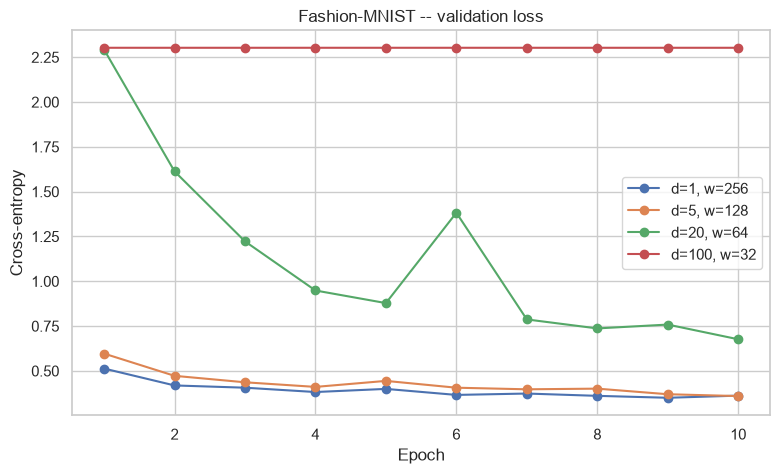

In [23]:
plt.figure(figsize=(9, 5))
for (depth, width), history in fashion_histories.items():
    plt.plot(history["epoch"], history["val_loss"], marker="o", label=f"d={depth}, w={width}")

plt.title("Fashion-MNIST -- validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy")
plt.legend()
plt.savefig(FIGURES_DIR / "fashion_learning_curve_val_loss.png", bbox_inches="tight")
plt.show()


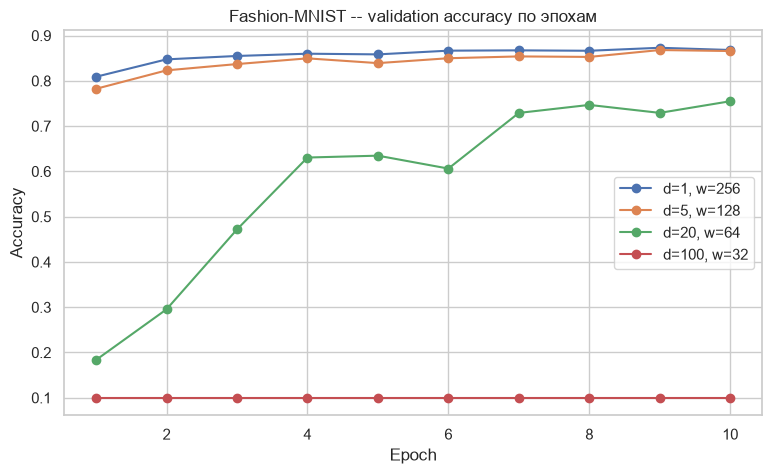

In [24]:
plt.figure(figsize=(9, 5))
for (depth, width), history in fashion_histories.items():
    plt.plot(history["epoch"], history["val_accuracy"], marker="o", label=f"d={depth}, w={width}")

plt.title("Fashion-MNIST -- validation accuracy по эпохам")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig(FIGURES_DIR / "fashion_learning_curve_accuracy.png", bbox_inches="tight")
plt.show()


## Shallow vs deep при одинаковом числе параметров

Теперь глубина меняется при фиксированном **бюджете параметров** (в начале объяснял, почему). 

Для каждого `depth` ширина выбирается только из формулы числа параметров.


In [25]:
matched_configs = pd.DataFrame([
    {
        "budget": budget,
        "depth": depth,
        "width": width_for_budget(depth, budget),
    }
    for budget in PARAMETER_BUDGETS
    for depth in MATCHED_DEPTHS
])

matched_configs["parameters"] = matched_configs.apply(
    lambda row: parameter_count(int(row["depth"]), int(row["width"])),
    axis=1,
)
matched_configs["relative_error"] = (
    (matched_configs["parameters"] - matched_configs["budget"]).abs()
    / matched_configs["budget"]
)

matched_configs


,budget,depth,width,parameters,relative_error
0,50000,1,63,50095,0.001900
1,50000,2,59,50455,0.009100
2,50000,5,50,49960,0.000800
3,50000,10,42,49654,0.006920
4,50000,20,34,49650,0.007000
5,50000,50,24,48490,0.030200
6,50000,100,18,48178,0.036440
7,150000,1,189,150265,0.001767
8,150000,2,157,149631,0.002460
9,150000,5,118,149988,0.000080


In [26]:
def run_matched_experiment(dataset_name, data):
    results = []

    for row in matched_configs.itertuples(index=False):
        print(f"{dataset_name}: budget={row.budget}, depth={row.depth}, width={row.width}")
        model, history, elapsed = fit_model(
            row.depth,
            row.width,
            data["grid"],
            data["val"],
            MATCHED_EPOCHS,
        )

        last = history.iloc[-1]
        results.append({
            "dataset": dataset_name,
            "budget": row.budget,
            "depth": row.depth,
            "width": row.width,
            "parameters": count_parameters(model),
            "val_accuracy": last["val_accuracy"],
            "val_macro_f1": last["val_macro_f1"],
            "train_time_sec": elapsed,
        })

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return pd.DataFrame(results)


mnist_matched = run_matched_experiment("MNIST", mnist_data)
mnist_matched.to_csv(REPORT_DIR / "mnist_parameter_matched.csv", index=False)
mnist_matched


MNIST: budget=50000, depth=1, width=63
MNIST: budget=50000, depth=2, width=59
MNIST: budget=50000, depth=5, width=50
MNIST: budget=50000, depth=10, width=42
MNIST: budget=50000, depth=20, width=34
MNIST: budget=50000, depth=50, width=24
MNIST: budget=50000, depth=100, width=18
MNIST: budget=150000, depth=1, width=189
MNIST: budget=150000, depth=2, width=157
MNIST: budget=150000, depth=5, width=118
MNIST: budget=150000, depth=10, width=92
MNIST: budget=150000, depth=20, width=70
MNIST: budget=150000, depth=50, width=47
MNIST: budget=150000, depth=100, width=35
MNIST: budget=500000, depth=1, width=629
MNIST: budget=500000, depth=2, width=413
MNIST: budget=500000, depth=5, width=268
MNIST: budget=500000, depth=10, width=195
MNIST: budget=500000, depth=20, width=142
MNIST: budget=500000, depth=50, width=93
MNIST: budget=500000, depth=100, width=67


,dataset,budget,depth,width,parameters,val_accuracy,val_macro_f1,train_time_sec
0,MNIST,50000,1,63,50095,0.9266,0.925967,0.721404
1,MNIST,50000,2,59,50455,0.9261,0.925277,0.884779
2,MNIST,50000,5,50,49960,0.9016,0.900558,1.057926
3,MNIST,50000,10,42,49654,0.8418,0.837324,1.425033
4,MNIST,50000,20,34,49650,0.2568,0.141695,2.057260
5,MNIST,50000,50,24,48490,0.1124,0.020209,3.808772
6,MNIST,50000,100,18,48178,0.1124,0.020209,6.641662
7,MNIST,150000,1,189,150265,0.9423,0.941815,1.029317
8,MNIST,150000,2,157,149631,0.9414,0.940919,0.844765
9,MNIST,150000,5,118,149988,0.9331,0.932519,1.025437


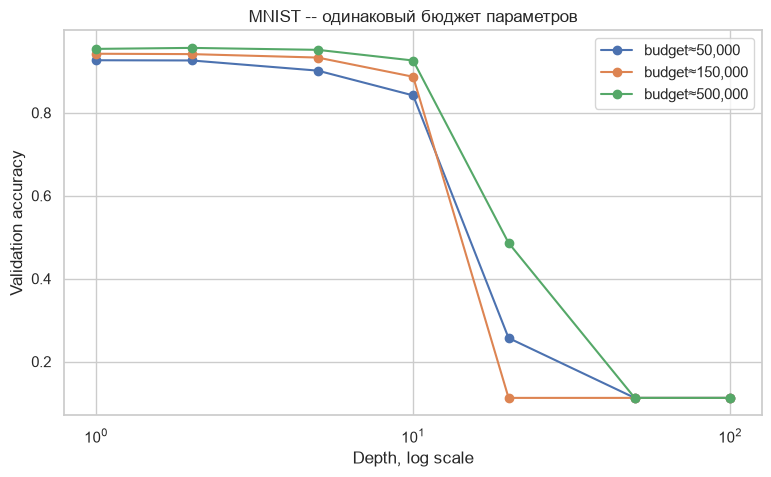

In [27]:
plt.figure(figsize=(9, 5))
for budget in PARAMETER_BUDGETS:
    part = mnist_matched[mnist_matched["budget"] == budget]
    plt.plot(part["depth"], part["val_accuracy"], marker="o", label=f"budget≈{budget:,}")

plt.xscale("log")
plt.title("MNIST -- одинаковый бюджет параметров")
plt.xlabel("Depth, log scale")
plt.ylabel("Validation accuracy")
plt.legend()
plt.savefig(FIGURES_DIR / "mnist_parameter_matched_accuracy.png", bbox_inches="tight")
plt.show()


In [28]:
fashion_matched = run_matched_experiment("Fashion-MNIST", fashion_data)
fashion_matched.to_csv(REPORT_DIR / "fashion_parameter_matched.csv", index=False)
fashion_matched


Fashion-MNIST: budget=50000, depth=1, width=63
Fashion-MNIST: budget=50000, depth=2, width=59
Fashion-MNIST: budget=50000, depth=5, width=50
Fashion-MNIST: budget=50000, depth=10, width=42
Fashion-MNIST: budget=50000, depth=20, width=34
Fashion-MNIST: budget=50000, depth=50, width=24
Fashion-MNIST: budget=50000, depth=100, width=18
Fashion-MNIST: budget=150000, depth=1, width=189
Fashion-MNIST: budget=150000, depth=2, width=157
Fashion-MNIST: budget=150000, depth=5, width=118
Fashion-MNIST: budget=150000, depth=10, width=92
Fashion-MNIST: budget=150000, depth=20, width=70
Fashion-MNIST: budget=150000, depth=50, width=47
Fashion-MNIST: budget=150000, depth=100, width=35
Fashion-MNIST: budget=500000, depth=1, width=629
Fashion-MNIST: budget=500000, depth=2, width=413
Fashion-MNIST: budget=500000, depth=5, width=268
Fashion-MNIST: budget=500000, depth=10, width=195
Fashion-MNIST: budget=500000, depth=20, width=142
Fashion-MNIST: budget=500000, depth=50, width=93
Fashion-MNIST: budget=5000

,dataset,budget,depth,width,parameters,val_accuracy,val_macro_f1,train_time_sec
0,Fashion-MNIST,50000,1,63,50095,0.8521,0.852392,0.668797
1,Fashion-MNIST,50000,2,59,50455,0.8473,0.847260,0.726924
2,Fashion-MNIST,50000,5,50,49960,0.8269,0.826402,0.951004
3,Fashion-MNIST,50000,10,42,49654,0.7535,0.751901,1.274168
4,Fashion-MNIST,50000,20,34,49650,0.4079,0.306744,1.825571
5,Fashion-MNIST,50000,50,24,48490,0.1000,0.018182,3.359832
6,Fashion-MNIST,50000,100,18,48178,0.1000,0.018182,5.787555
7,Fashion-MNIST,150000,1,189,150265,0.8560,0.856580,0.648106
8,Fashion-MNIST,150000,2,157,149631,0.8532,0.853841,0.701604
9,Fashion-MNIST,150000,5,118,149988,0.8395,0.839354,0.946383


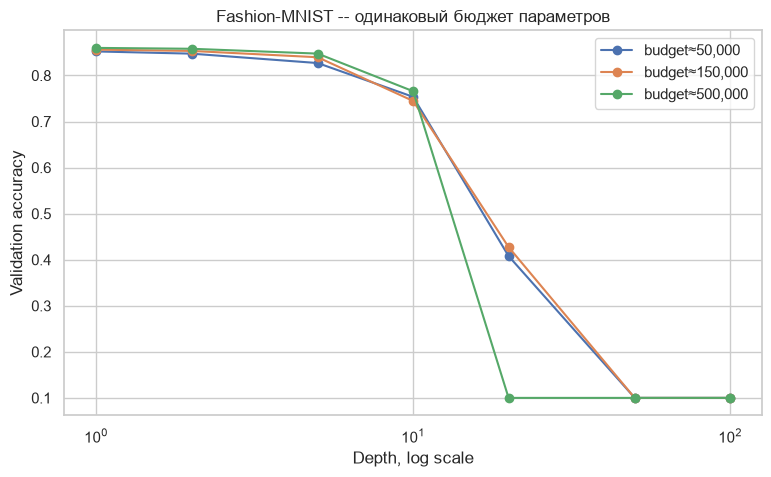

In [29]:
plt.figure(figsize=(9, 5))
for budget in PARAMETER_BUDGETS:
    part = fashion_matched[fashion_matched["budget"] == budget]
    plt.plot(part["depth"], part["val_accuracy"], marker="o", label=f"budget≈{budget:,}")

plt.xscale("log")
plt.title("Fashion-MNIST -- одинаковый бюджет параметров")
plt.xlabel("Depth, log scale")
plt.ylabel("Validation accuracy")
plt.legend()
plt.savefig(FIGURES_DIR / "fashion_parameter_matched_accuracy.png", bbox_inches="tight")
plt.show()


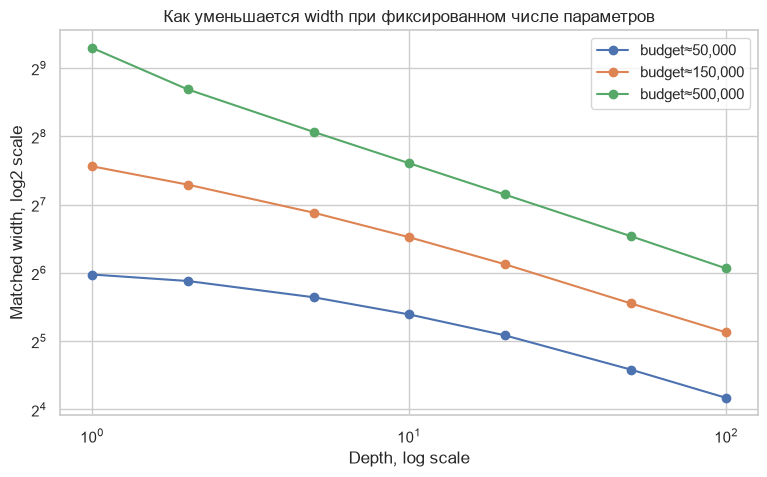

In [30]:
plt.figure(figsize=(9, 5))
for budget in PARAMETER_BUDGETS:
    part = matched_configs[matched_configs["budget"] == budget]
    plt.plot(part["depth"], part["width"], marker="o", label=f"budget≈{budget:,}")

plt.xscale("log")
plt.yscale("log", base=2)
plt.title("Как уменьшается width при фиксированном числе параметров")
plt.xlabel("Depth, log scale")
plt.ylabel("Matched width, log2 scale")
plt.legend()
plt.savefig(FIGURES_DIR / "matched_width_vs_depth.png", bbox_inches="tight")
plt.show()


## Финальная оценка MLP на test

Теперь выбираю лучшую пару `(depth, width)` только по validation accuracy, переобучаю эту архитектуру на всей официальной train-части и один раз считаю test-метрики.


In [31]:
def fit_without_validation(depth, width, train_dataset, epochs):
    set_seed()

    model = MLP(depth, width).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.CrossEntropyLoss()
    train_loader = make_loader(train_dataset, shuffle=True)

    history = []
    started = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(y_batch)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss / len(train_dataset),
        })

    return model, pd.DataFrame(history), time.perf_counter() - started


def final_test(dataset_name, dataset_class, grid_results):
    best = grid_results.sort_values("val_accuracy", ascending=False).iloc[0]
    data = load_dataset(dataset_class)
    train_dataset = data["train"]
    test_dataset = data["test"]

    model, history, elapsed = fit_without_validation(
        int(best["depth"]),
        int(best["width"]),
        train_dataset,
        FINAL_EPOCHS,
    )
    metrics = evaluate(model, make_loader(test_dataset), nn.CrossEntropyLoss())

    result = {
        "dataset": dataset_name,
        "depth": int(best["depth"]),
        "width": int(best["width"]),
        "parameters": count_parameters(model),
        "selection_val_accuracy": best["val_accuracy"],
        "test_accuracy": metrics["accuracy"],
        "test_macro_f1": metrics["macro_f1"],
        "train_time_sec": elapsed,
    }
    return model, metrics, result


mnist_final_model, mnist_test_metrics, mnist_final = final_test(
    "MNIST", MNIST, mnist_grid_results
)
fashion_final_model, fashion_test_metrics, fashion_final = final_test(
    "Fashion-MNIST", FashionMNIST, fashion_grid_results
)

final_results = pd.DataFrame([mnist_final, fashion_final])
final_results.to_csv(REPORT_DIR / "mlp_final_results.csv", index=False)
final_results


,dataset,depth,width,parameters,selection_val_accuracy,test_accuracy,test_macro_f1,train_time_sec
0,MNIST,3,256,335114,0.9522,0.9776,0.977437,3.948315
1,Fashion-MNIST,5,256,466698,0.8570,0.8749,0.873897,5.131776


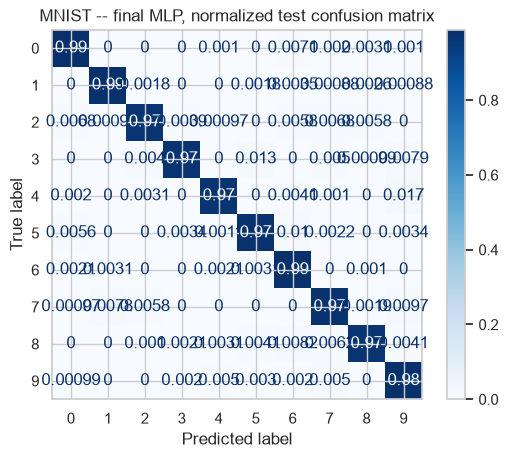

In [32]:
ConfusionMatrixDisplay.from_predictions(
    mnist_test_metrics["y_true"],
    mnist_test_metrics["y_pred"],
    cmap="Blues",
    normalize="true",
)
plt.title("MNIST -- final MLP, normalized test confusion matrix")
plt.savefig(FIGURES_DIR / "mnist_mlp_confusion_matrix.png", bbox_inches="tight")
plt.show()


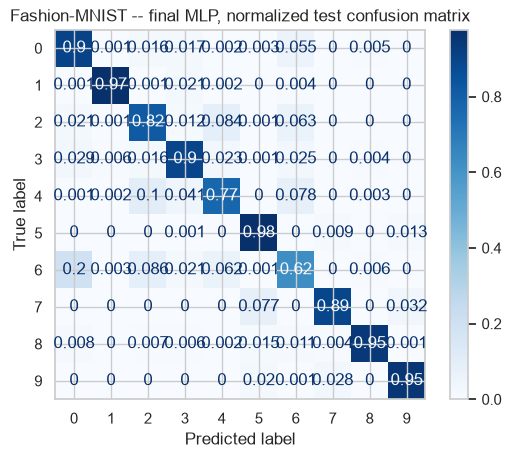

In [33]:
ConfusionMatrixDisplay.from_predictions(
    fashion_test_metrics["y_true"],
    fashion_test_metrics["y_pred"],
    cmap="Blues",
    normalize="true",
)
plt.title("Fashion-MNIST -- final MLP, normalized test confusion matrix")
plt.savefig(FIGURES_DIR / "fashion_mlp_confusion_matrix.png", bbox_inches="tight")
plt.show()


На обоих датасетах получилось в общем-то хорошо. На `Fashion` результаты, тем не менее, похуже: предсказываем класс $0$ при исходном $6$, т.е. путаем T-thirt и Shirt. Если вернуться в [EDA](/notebooks/00_EDA.ipynb), то увидим, что силуэты действительно очень схожи.